# PSD spectra, cluster permutation test, and per-band Wilcoxon

Reproduces the resting-EEG power figures and the spectral statistical tests comparing **ketamine** vs **awake** eyes-closed recordings.

* **Figure** grand-average power spectrum + log-power ratio with significant clusters
* **Figure** per-subject spectra
* **Statistical test** cluster-based permutation test (paired, within-subject) on log power, 1-40 Hz
* **Statistical test** per-band Wilcoxon signed-rank tests (Holm-corrected)

All panels are computed from the cached per-recording PSDs (`data/derived/features/psd_grandavg_cache.npz`), so no raw EEG is needed. Delete the cache and run `scripts/` feature extraction to recompute it from raw.

In [1]:
import sys, pathlib
for _cand in (pathlib.Path.cwd(), pathlib.Path.cwd().parent):
    if (_cand / "src" / "ketamine_eeg").exists():
        sys.path.insert(0, str(_cand / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ketamine_eeg import config as c
from ketamine_eeg.plotting import apply_style, fig_width
apply_style()
c.ensure_dirs()
print("ketamine_eeg loaded; figures ->", c.FIGURE_DIR.relative_to(c.PROJECT_ROOT))

ketamine_eeg loaded; figures -> results/figures


In [2]:
# Cached per-recording PSDs: awake/ketamine arrays are (n_subjects, n_channels, n_freqs)
cache = np.load(c.PSD_CACHE_PATH)
freqs, awake, ketamine = cache["freqs"], cache["awake"], cache["ketamine"]
psds = {"awake": awake, "ketamine": ketamine}
BANDS_HZ = c.BANDS_HZ
COLORS = c.COND_COLORS
BAND_SHADE = {"delta": "#e8e8e8", "theta": "#d8eaf7", "alpha": "#d4f0d4", "beta": "#fce8d4"}
n_subj = awake.shape[0]
print(f"awake {awake.shape} | ketamine {ketamine.shape} | {len(freqs)} freq bins | {n_subj} subjects")

awake (10, 62, 79) | ketamine (10, 62, 79) | 79 freq bins | 10 subjects


## Cluster-based permutation test (paired, within-subject)
Within-subject log-power difference (ketamine - awake), averaged over channels, tested at every frequency bin with a sign-flip cluster permutation test (10,000 permutations; t-threshold 2.262 = df 9, p=0.05 two-tailed).

In [3]:
from mne.stats import permutation_cluster_1samp_test

awake_lp = np.log(awake.mean(axis=1))        # (n_subj, n_freqs)
ketamine_lp = np.log(ketamine.mean(axis=1))
diff_lp = ketamine_lp - awake_lp

T_OBS, clusters, cluster_pv, _ = permutation_cluster_1samp_test(
    diff_lp, n_permutations=10_000, threshold=2.262, tail=0,
    out_type="mask", seed=c.SEED, verbose=False,
)
sig_ranges = []
print(f"{len(clusters)} cluster(s):")
for i, (cmask, p) in enumerate(zip(clusters, cluster_pv)):
    idx = np.where(cmask)[0] if not isinstance(cmask, tuple) else np.arange(*cmask[0].indices(len(freqs)))
    direction = "ketamine > awake" if T_OBS[idx].mean() > 0 else "ketamine < awake"
    flag = " *" if p < 0.05 else ""
    print(f"  cluster {i+1}: {freqs[idx].min():5.2f}-{freqs[idx].max():5.2f} Hz  p={p:.4f}{flag}  {direction}")
    if p < 0.05:
        sig_ranges.append((freqs[idx].min(), freqs[idx].max()))

4 cluster(s):
  cluster 1: 37.50-38.00 Hz  p=0.3340  ketamine > awake
  cluster 2:  1.50- 9.00 Hz  p=0.0137 *  ketamine < awake
  cluster 3: 11.00-12.50 Hz  p=0.1621  ketamine < awake
  cluster 4: 13.50-24.50 Hz  p=0.0039 *  ketamine < awake


## Figure: grand-average spectrum + log-power ratio with significant clusters

saved psd_combined.png / .pdf


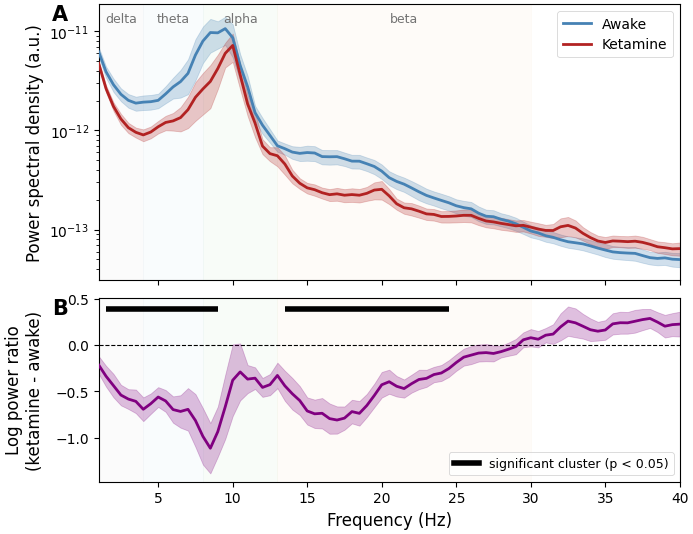

In [4]:
from matplotlib.lines import Line2D

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(fig_width("double"), 6.2), sharex=True,
                                     gridspec_kw={"height_ratios": [3, 2], "hspace": 0.08})
for ax in (ax_top, ax_bot):
    for band, (flo, fhi) in BANDS_HZ.items():
        ax.axvspan(flo, fhi, alpha=0.14, color=BAND_SHADE[band], zorder=0)
for band, (flo, fhi) in BANDS_HZ.items():
    ax_top.annotate(band, xy=((flo+fhi)/2, 0.97), xycoords=("data", "axes fraction"),
                    ha="center", va="top", fontsize=9, color="0.45")

for drug, color in COLORS.items():
    per_subj = psds[drug].mean(axis=1)
    grand = per_subj.mean(axis=0)
    sem = per_subj.std(axis=0) / np.sqrt(len(per_subj))
    ax_top.semilogy(freqs, grand, color=color, lw=2, zorder=3)
    ax_top.fill_between(freqs, np.maximum(grand-sem, 1e-30), grand+sem, alpha=0.25, color=color, zorder=2)
ax_top.set_ylabel("Power spectral density (a.u.)")
ax_top.legend(handles=[Line2D([0],[0],color=COLORS["awake"],lw=2,label="Awake"),
                       Line2D([0],[0],color=COLORS["ketamine"],lw=2,label="Ketamine")],
              loc="upper right")
ax_top.text(-0.08, 1.0, "A", transform=ax_top.transAxes, fontsize=15, fontweight="bold", va="top")

ax_bot.axhline(0, color="black", lw=0.8, ls="--", zorder=1)
grand_ratio = diff_lp.mean(axis=0); sem_ratio = diff_lp.std(axis=0)/np.sqrt(n_subj)
ax_bot.plot(freqs, grand_ratio, color="purple", lw=2, zorder=3)
ax_bot.fill_between(freqs, grand_ratio-sem_ratio, grand_ratio+sem_ratio, alpha=0.25, color="purple", zorder=2)
ylim = ax_bot.get_ylim(); bar_y = ylim[1] - 0.06*(ylim[1]-ylim[0])
for flo, fhi in sig_ranges:
    m = (freqs >= flo) & (freqs <= fhi)
    ax_bot.plot(freqs[m], np.full(m.sum(), bar_y), color="black", lw=4, solid_capstyle="butt", zorder=4)
if sig_ranges:
    ax_bot.legend(handles=[Line2D([0],[0],color="black",lw=4,label="significant cluster (p < 0.05)")],
                  loc="lower right", fontsize=9)
ax_bot.set_ylim(ylim)
ax_bot.set_ylabel("Log power ratio\n(ketamine - awake)")
ax_bot.set_xlabel("Frequency (Hz)")
ax_bot.set_xlim(c.PSD_FMIN, c.PSD_FMAX)
ax_bot.text(-0.08, 1.0, "B", transform=ax_bot.transAxes, fontsize=15, fontweight="bold", va="top")
fig.align_ylabels([ax_top, ax_bot])
fig.savefig(c.FIGURE_DIR / "psd_combined.png", dpi=300, bbox_inches="tight")
fig.savefig(c.FIGURE_DIR / "psd_combined.pdf", bbox_inches="tight")
print("saved psd_combined.png / .pdf")
plt.show()

## Figure: per-subject spectra

saved psd_per_subject.png


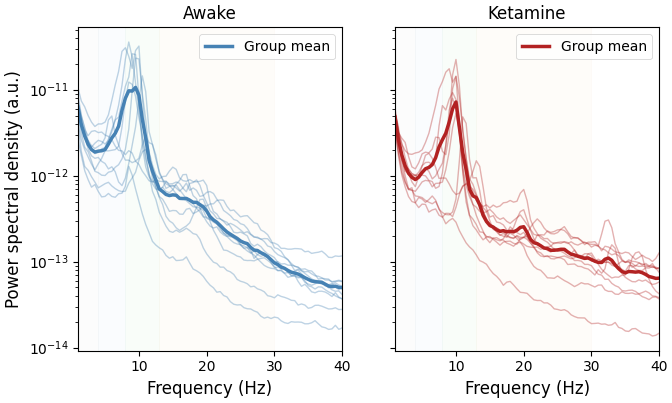

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(fig_width("double"), 4.2), sharey=True)
for ax, drug in zip(axes, ["awake", "ketamine"]):
    per_subj = psds[drug].mean(axis=1)
    for i in range(n_subj):
        ax.semilogy(freqs, per_subj[i], color=COLORS[drug], alpha=0.35, lw=1)
    ax.semilogy(freqs, per_subj.mean(axis=0), color=COLORS[drug], lw=2.5, label="Group mean")
    for band, (flo, fhi) in BANDS_HZ.items():
        ax.axvspan(flo, fhi, alpha=0.12, color=BAND_SHADE[band])
    ax.set_xlabel("Frequency (Hz)"); ax.set_xlim(c.PSD_FMIN, c.PSD_FMAX)
    ax.set_title(drug.capitalize()); ax.legend()
axes[0].set_ylabel("Power spectral density (a.u.)")
fig.savefig(c.FIGURE_DIR / "psd_per_subject.png", dpi=300, bbox_inches="tight")
print("saved psd_per_subject.png")
plt.show()

## Statistical test: per-band Wilcoxon signed-rank (Holm-corrected)
Each subject contributes one log-power difference (ketamine - awake) per band; the table is written to `results/tables/psd_band_wilcoxon.csv`.

In [6]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

rows = []
for band, (flo, fhi) in BANDS_HZ.items():
    fmask = (freqs >= flo) & (freqs < fhi)
    a = np.log(awake[:, :, fmask].mean(axis=(1, 2)))
    k = np.log(ketamine[:, :, fmask].mean(axis=(1, 2)))
    d = k - a
    w_stat, w_p = stats.wilcoxon(d, alternative="two-sided", zero_method="wilcox", mode="exact")
    rows.append({"band": band, "freq_range_Hz": f"{flo}-{fhi}",
                 "mean_log_diff": float(d.mean()), "median_log_diff": float(np.median(d)),
                 "n_pos": int((d > 0).sum()), "n_neg": int((d < 0).sum()),
                 "W": float(w_stat), "p": float(w_p)})
band_df = pd.DataFrame(rows)
reject, p_adj, _, _ = multipletests(band_df["p"].values, method="holm")
band_df["p_holm"] = p_adj
band_df["significant"] = reject
band_df.to_csv(c.TABLES_DIR / "psd_band_wilcoxon.csv", index=False)
print("saved results/tables/psd_band_wilcoxon.csv")
band_df.round(4)

saved results/tables/psd_band_wilcoxon.csv


,band,freq_range_Hz,mean_log_diff,median_log_diff,n_pos,n_neg,W,p,p_holm,significant
0,delta,1.0-4.0,-0.3701,-0.4285,2,8,5.0,0.0195,0.0391,True
1,theta,4.0-8.0,-0.7061,-0.6974,0,10,0.0,0.0020,0.0078,True
2,alpha,8.0-13.0,-0.6373,-0.8148,1,9,7.0,0.0371,0.0391,True
3,beta,13.0-30.0,-0.4849,-0.4206,0,10,0.0,0.0020,0.0078,True
